In [45]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [46]:
df.shape

(103904, 25)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [48]:
df = df.drop(columns=["Unnamed: 0", "id"])
df.shape

(103904, 23)

In [49]:
missing = df.isnull().sum()
missing_rate = (missing / len(df)) * 100
print(missing_rate[missing_rate>0])

Arrival Delay in Minutes    0.298352
dtype: float64


In [50]:
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class", "satisfaction"]

for col in categorical_cols:
    print(col)
    print()
    print(df[col].value_counts())
    print()

Gender

Gender
Female    52727
Male      51177
Name: count, dtype: int64

Customer Type

Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

Type of Travel

Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

Class

Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

satisfaction

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64



In [51]:
print(df["satisfaction"].value_counts())
print()
print(df["satisfaction"].value_counts(normalize=True) * 100)

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64


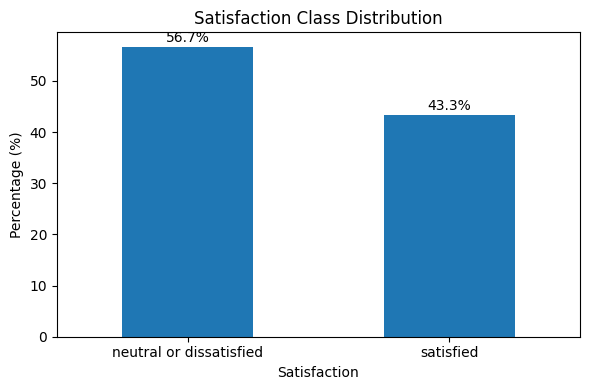

In [52]:
import matplotlib.pyplot as plt

target_ratio = df["satisfaction"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
target_ratio.plot(kind="bar")

plt.title("Satisfaction Class Distribution")
plt.ylabel("Percentage (%)")
plt.xlabel("Satisfaction")
plt.xticks(rotation=0)

for i, value in enumerate(target_ratio):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.0,3.0,4.0,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.0,3.0,4.0,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.0,3.0,4.0,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.0,3.0,4.0,5.0
Seat comfort,103904.0,3.439396,1.319088,0.0,2.0,4.0,5.0,5.0
Inflight entertainment,103904.0,3.358158,1.332991,0.0,2.0,4.0,4.0,5.0


어떤 종류의 승객이 더 만족하는가?

In [54]:
gender_sat = pd.crosstab(
    df["Gender"],
    df["satisfaction"],
    normalize="index"
) * 100

print(gender_sat)

satisfaction  neutral or dissatisfied  satisfied
Gender                                          
Female                      57.262882  42.737118
Male                        56.052524  43.947476


In [55]:
customer_sat = pd.crosstab(
    df["Customer Type"],
    df["satisfaction"],
    normalize="index"
) * 100

print(customer_sat)

satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Loyal Customer                   52.270881  47.729119
disloyal Customer                76.334229  23.665771


In [56]:
travel_sat = pd.crosstab(
    df["Type of Travel"],
    df["satisfaction"],
    normalize="index"
) * 100

print(travel_sat)

satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                41.740283  58.259717
Personal Travel                89.832243  10.167757


In [57]:
class_sat = pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
) * 100

print(class_sat)

satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                    30.574852  69.425148
Eco                         81.386245  18.613755
Eco Plus                    75.393648  24.606352


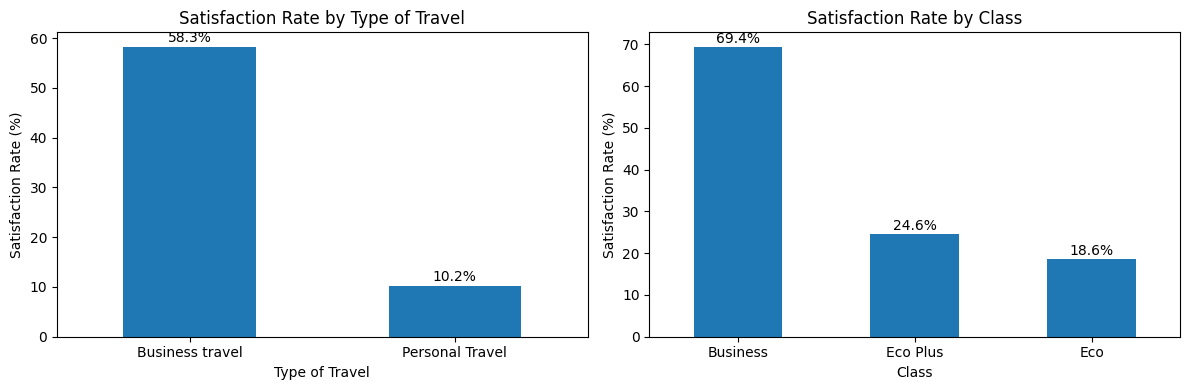

In [58]:
travel_rate = (
    df.groupby("Type of Travel")["satisfaction"]
      .apply(lambda x: (x == "satisfied").mean() * 100)
      .sort_values(ascending=False)
)

class_rate = (
    df.groupby("Class")["satisfaction"]
      .apply(lambda x: (x == "satisfied").mean() * 100)
      .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

travel_rate.plot(kind="bar", ax=axes[0])
axes[0].set_title("Satisfaction Rate by Type of Travel")
axes[0].set_ylabel("Satisfaction Rate (%)")
axes[0].set_xlabel("Type of Travel")
axes[0].tick_params(axis="x", rotation=0)

for i, value in enumerate(travel_rate):
    axes[0].text(i, value + 1, f"{value:.1f}%", ha="center")


class_rate.plot(kind="bar", ax=axes[1])
axes[1].set_title("Satisfaction Rate by Class")
axes[1].set_ylabel("Satisfaction Rate (%)")
axes[1].set_xlabel("Class")
axes[1].tick_params(axis="x", rotation=0)

for i, value in enumerate(class_rate):
    axes[1].text(i, value + 1, f"{value:.1f}%", ha="center")


plt.tight_layout()
plt.show()

Gender
→ 만족률 차이 거의 없음

Customer Type
→ Loyal Customer가 더 높은 만족률

Type of Travel
→ Business travel의 만족률이 훨씬 높음

Class
→ Business Class의 만족률이 훨씬 높음

만족한 승객과 불만족한 승객은 어떤 서비스에서 평가가 가장 크게 다른가?

In [59]:
service_cols = df.loc[:, "Inflight wifi service":"Cleanliness"].columns.tolist()

In [60]:
service_mean = df.groupby("satisfaction")[service_cols].mean()

service_mean = service_mean.T

print(service_mean)

satisfaction                       neutral or dissatisfied  satisfied
Inflight wifi service                             2.399633   3.161288
Departure/Arrival time convenient                 3.129112   2.970305
Ease of Online booking                            2.546850   3.031582
Gate location                                     2.976121   2.977879
Food and drink                                    2.958050   3.521310
Online boarding                                   2.656125   4.027474
Seat comfort                                      3.036295   3.966530
Inflight entertainment                            2.894156   3.964931
On-board service                                  3.019158   3.857324
Leg room service                                  2.990812   3.822143
Baggage handling                                  3.375991   3.966396
Checkin service                                   3.042952   3.646041
Inflight service                                  3.388814   3.969461
Cleanliness         

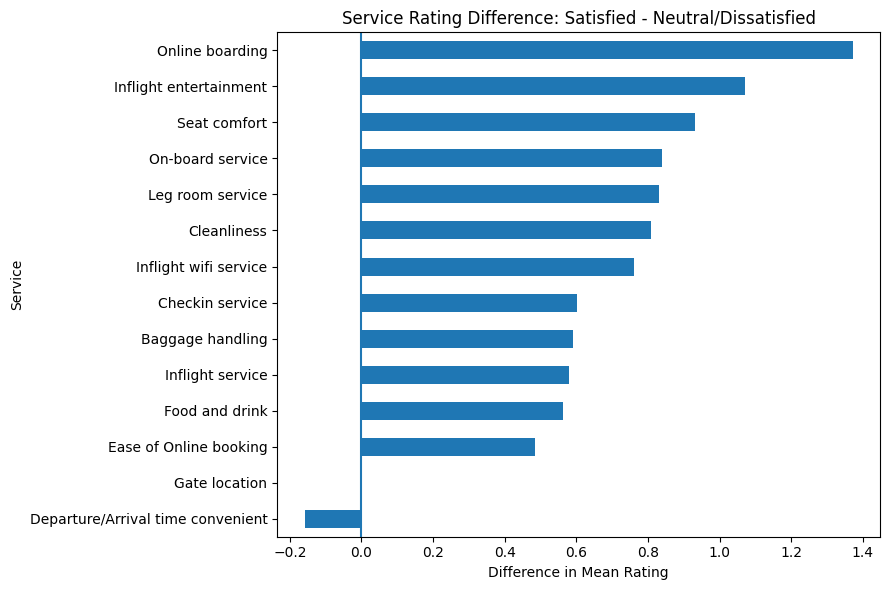

In [61]:
service_diff = (
    service_mean["satisfied"]
    - service_mean["neutral or dissatisfied"]
).sort_values()

plt.figure(figsize=(9, 6))

service_diff.plot(kind="barh")

plt.title("Service Rating Difference: Satisfied - Neutral/Dissatisfied")
plt.xlabel("Difference in Mean Rating")
plt.ylabel("Service")

plt.axvline(0)

plt.tight_layout()
plt.show()

In [62]:
service_mean["difference"] = (service_mean["satisfied"] - service_mean["neutral or dissatisfied"])

service_mean = service_mean.sort_values("difference",ascending=False)

print(service_mean)

satisfaction                       neutral or dissatisfied  satisfied  \
Online boarding                                   2.656125   4.027474   
Inflight entertainment                            2.894156   3.964931   
Seat comfort                                      3.036295   3.966530   
On-board service                                  3.019158   3.857324   
Leg room service                                  2.990812   3.822143   
Cleanliness                                       2.936123   3.744342   
Inflight wifi service                             2.399633   3.161288   
Checkin service                                   3.042952   3.646041   
Baggage handling                                  3.375991   3.966396   
Inflight service                                  3.388814   3.969461   
Food and drink                                    2.958050   3.521310   
Ease of Online booking                            2.546850   3.031582   
Gate location                                     2

만족 승객과 불만족 승객 간 Online boarding 평가에서 가장 큰 평균 차이가 관찰되었다.

In [63]:
delay_mean = df.groupby("satisfaction")[["Departure Delay in Minutes","Arrival Delay in Minutes"]].mean()

print(delay_mean)

                         Departure Delay in Minutes  Arrival Delay in Minutes
satisfaction                                                                 
neutral or dissatisfied                   16.503728                 17.127536
satisfied                                 12.608084                 12.630799


만족 승객 집단의 평균 출발·도착 지연 시간이 불만족/중립 승객보다 짧게 나타났다.

승객 만족도는 성별보다는 여행 목적과 좌석 등급에 따라 큰 차이를 보였으며, 서비스 항목 중에서는 Online boarding, Inflight entertainment, Seat comfort 등에서 만족/불만족 승객 간 평균 평가 차이가 크게 나타났다. 또한 만족 승객의 평균 지연시간이 상대적으로 짧았다.

In [64]:
age_mean = df.groupby("satisfaction")["Age"].mean()

print(age_mean)

satisfaction
neutral or dissatisfied    37.566688
satisfied                  41.750583
Name: Age, dtype: float64


In [65]:
age_df = df.copy()

age_df["AgeGroup"] = pd.cut(
    age_df["Age"],
    bins=[0, 19, 29, 39, 49, 59, 69, 100],
    labels=["~19", "20s", "30s", "40s", "50s", "60s", "70+"]
)

age_sat = pd.crosstab(
    age_df["AgeGroup"],
    age_df["satisfaction"],
    normalize="index"
) * 100

print(age_sat)

satisfaction  neutral or dissatisfied  satisfied
AgeGroup                                        
~19                         82.054418  17.945582
20s                         64.511810  35.488190
30s                         58.802459  41.197541
40s                         41.884706  58.115294
50s                         42.815265  57.184735
60s                         71.986580  28.013420
70+                         78.295703  21.704297


In [66]:
distance_mean = df.groupby("satisfaction")["Flight Distance"].mean()
print(distance_mean)

satisfaction
neutral or dissatisfied     928.919971
satisfied                  1530.140255
Name: Flight Distance, dtype: float64


In [67]:
distance_df = df.copy()

distance_df["DistanceGroup"] = pd.qcut(distance_df["Flight Distance"], q=4)

distance_sat = pd.crosstab(
    distance_df["DistanceGroup"],
    distance_df["satisfaction"],
    normalize="index"
) * 100

print(distance_sat)

satisfaction      neutral or dissatisfied  satisfied
DistanceGroup                                       
(30.999, 414.0]                 66.309956  33.690044
(414.0, 843.0]                  67.583588  32.416412
(843.0, 1743.0]                 60.691170  39.308830
(1743.0, 4983.0]                32.080702  67.919298


비행거리가 긴 승객군에서 높은 만족률이 관찰되었다. 특히 상위 장거리 그룹의 만족률이 약 68%로 나타났다.

In [68]:
corr_df = df.copy()

corr_df["satisfaction_num"] = corr_df["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

correlation = (corr_df.select_dtypes(include="number").corr()["satisfaction_num"].sort_values(ascending=False))
print(correlation)

satisfaction_num                     1.000000
Online boarding                      0.503557
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Flight Distance                      0.298780
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Ease of Online booking               0.171705
Age                                  0.137167
Gate location                        0.000682
Departure Delay in Minutes          -0.050494
Departure/Arrival time convenient   -0.051601
Arrival Delay in Minutes            -0.057582
Name: satisfaction_num, dtype: float64


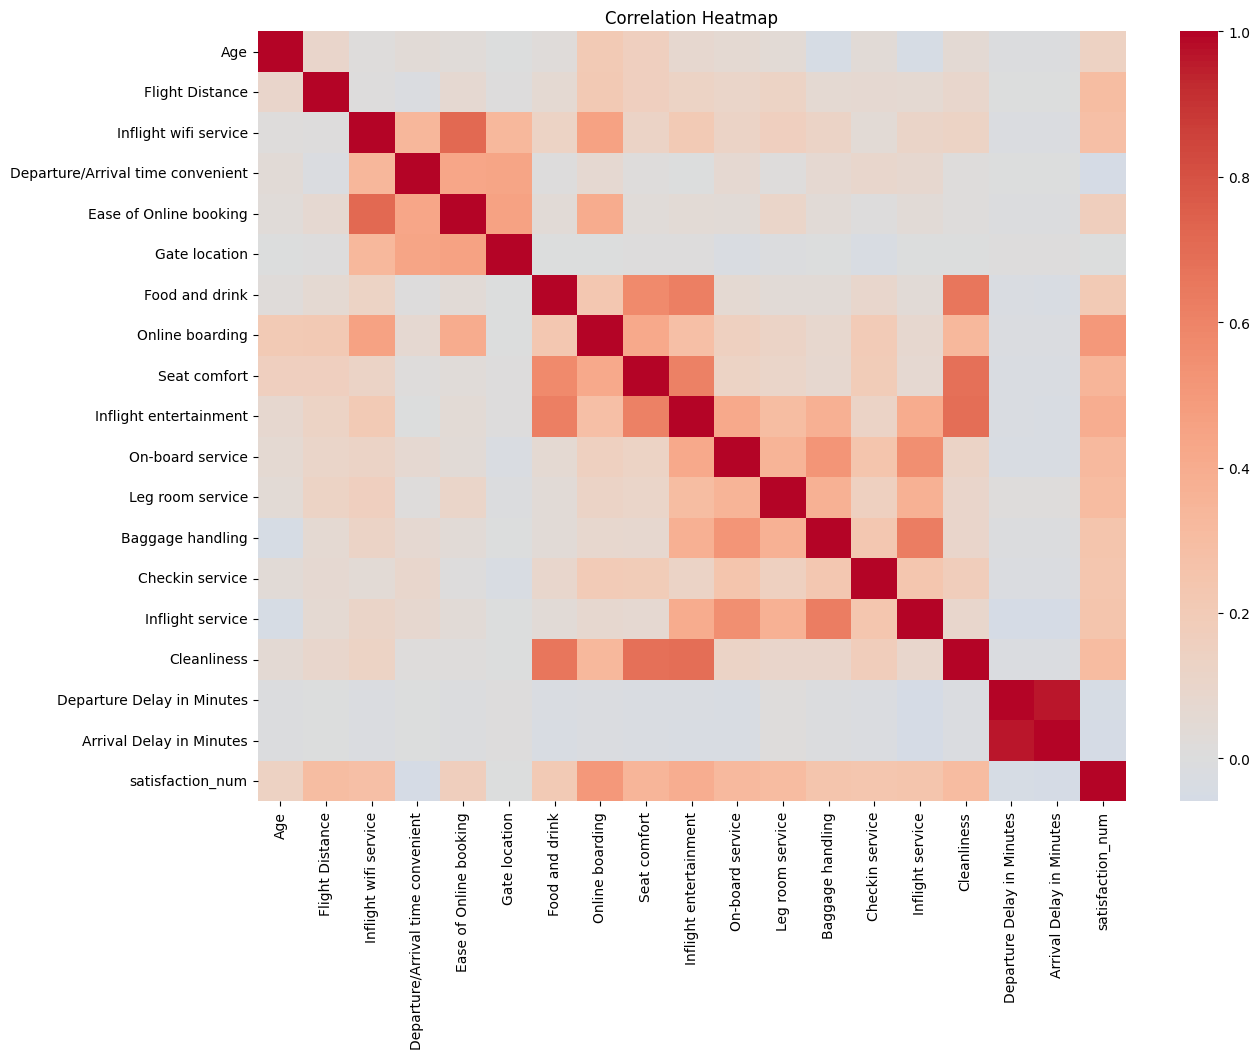

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = corr_df.select_dtypes(include="number")

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

EDA

| 변수                        | 관찰                             
| -------------------------- | -------------------------        
| Gender                     | 만족률 차이가 작음                
| Customer Type              | Loyal Customer 만족률 높음     
| Type of Travel             | Business travel 만족률 크게 높음 
| Class                      | Business 만족률 크게 높음        
| Age                        | 40~50대 만족률 상대적으로 높음       
| Flight Distance            | 장거리 그룹 만족률 높음             
| Online boarding            | 만족/불만족 간 차이가 매우 큼         
| Entertainment/Seat comfort | 역시 큰 차이                   
| Delay                      | 만족 승객의 평균 지연시간이 짧음        
| Departure/Arrival Delay    | 두 변수끼리 매우 높은 상관           
